# 03: Model Development (Price Prediction)

This notebook satisfies the Chapter 4 rubric using the refactored feature-target pipeline.

## Chapter 4: Model Development

- Primary Model (Assigned Technique): **Linear Regression**
- Two Comparative Models: **Ridge Regression**, **Huber Regression**
- Hyperparameter Tuning: Time-series cross-validation with grid search
- Model Justification: Compare generalization metrics and residual behavior

In [101]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)

In [102]:
CONFIG_PATH = Path("../data/processed/modeling_config.json")
cfg = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

data_csv = Path(cfg["data_csv"])
df = pd.read_csv(data_csv, index_col=0, parse_dates=True)

feature_cols = cfg["feature_cols"]
target_col = cfg["target_col"]

In [103]:
split_idx = int(len(df) * 0.9)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Configured target:", target_col)
print("Configured features:", feature_cols)

print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")

print(f"Train period: {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Test period:  {test_df.index.min().date()} -> {test_df.index.max().date()}")


Configured target: target_close_1d
Configured features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14', 'volume']
Train rows: 2232
Test rows:  248
Train period: 2016-05-31 -> 2025-04-14
Test period:  2025-04-15 -> 2026-04-10


In [104]:
def regression_metrics(y_true, y_pred, model_name: str) -> pd.DataFrame:
    metrics = {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }
    return pd.DataFrame([metrics]).round(4)


In [105]:
# Primary model: Linear Regression
lin_model = LinearRegression()

lin_model.fit(X_train, y_train)
lin_pred_train = lin_model.predict(X_train)
lin_pred_test = lin_model.predict(X_test)


lin_metrics_test = regression_metrics(y_test, lin_pred_test, "LinearRegression (test)")
lin_metrics_train = regression_metrics(y_train, lin_pred_train, "LinearRegression (train)")

print(lin_metrics_train.round(4))

print(lin_metrics_test.round(4))

                      Model     MAE    RMSE    MAPE      R2
0  LinearRegression (train)  2.1062  3.2526  0.0192  0.9976
                     Model     MAE   RMSE    MAPE      R2
0  LinearRegression (test)  4.2444  5.634  0.0178  0.9589


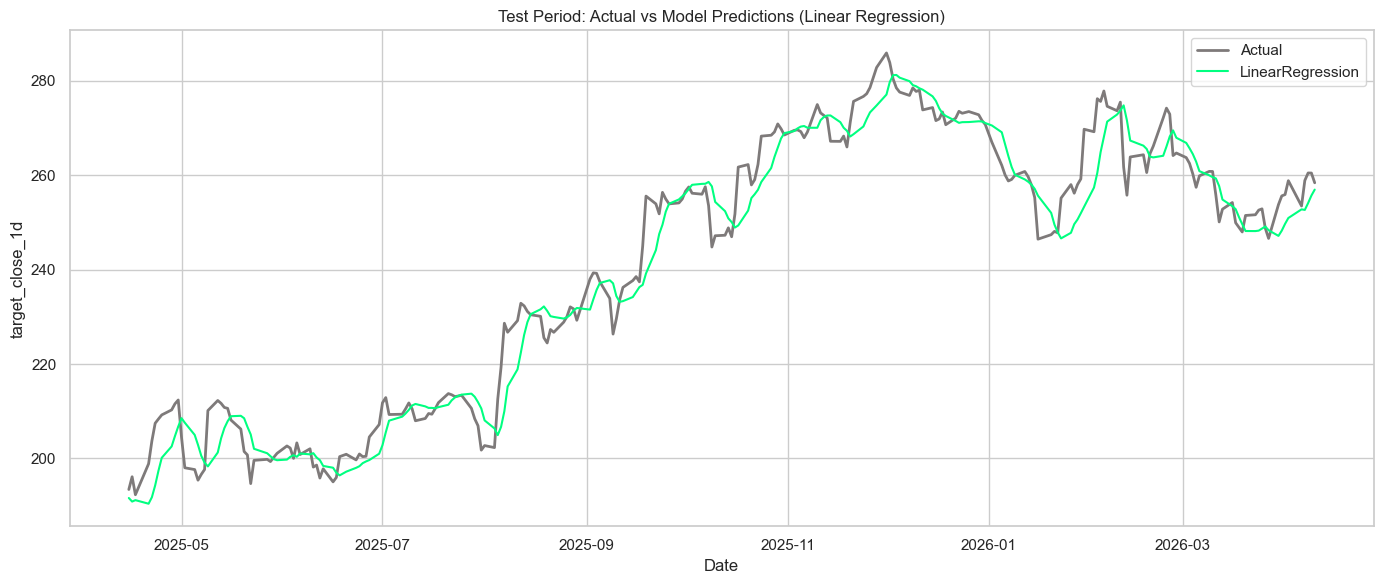

In [111]:
pred_df = pd.DataFrame(index=y_test.index)
pred_df["Actual"] = y_test
pred_df["LinearRegression"] = lin_pred_test

plt.figure(figsize=(14, 6))
plt.plot(pred_df.index, pred_df["Actual"], label="Actual", linewidth=2, color="#7E7A7A")
plt.plot(pred_df.index, pred_df["LinearRegression"], label="LinearRegression", color="#00FF80")
plt.title(f"Test Period: Actual vs Model Predictions (Linear Regression)")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


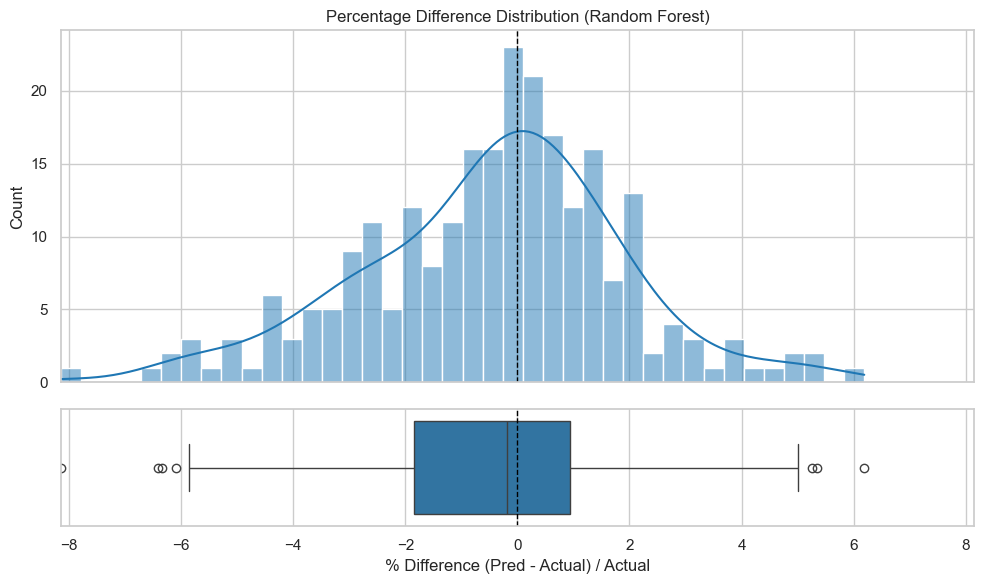

In [107]:
y_test_arr = np.asarray(y_test)
best_pred_arr = np.asarray(lin_pred_test)
pct_diff = np.where(y_test_arr != 0, ((best_pred_arr - y_test_arr) / y_test_arr) * 100, np.nan)

valid_pct_diff = pct_diff[~np.isnan(pct_diff)]
if valid_pct_diff.size == 0:
    valid_pct_diff = np.array([0.0])
abs_limit = np.max(np.abs(valid_pct_diff))
if abs_limit == 0:
    abs_limit = 1

fig, axes = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

sns.histplot(valid_pct_diff, bins=40, kde=True, ax=axes[0], color="#1f77b4")
axes[0].axvline(0, linestyle="--", color="black", linewidth=1)
axes[0].set_title("Percentage Difference Distribution (Random Forest)")
axes[0].set_ylabel("Count")

sns.boxplot(x=valid_pct_diff, ax=axes[1], color="#1f77b4")
axes[1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_xlabel("% Difference (Pred - Actual) / Actual")

axes[0].set_xlim(-abs_limit, abs_limit)
axes[1].set_xlim(-abs_limit, abs_limit)

plt.tight_layout()
plt.show()


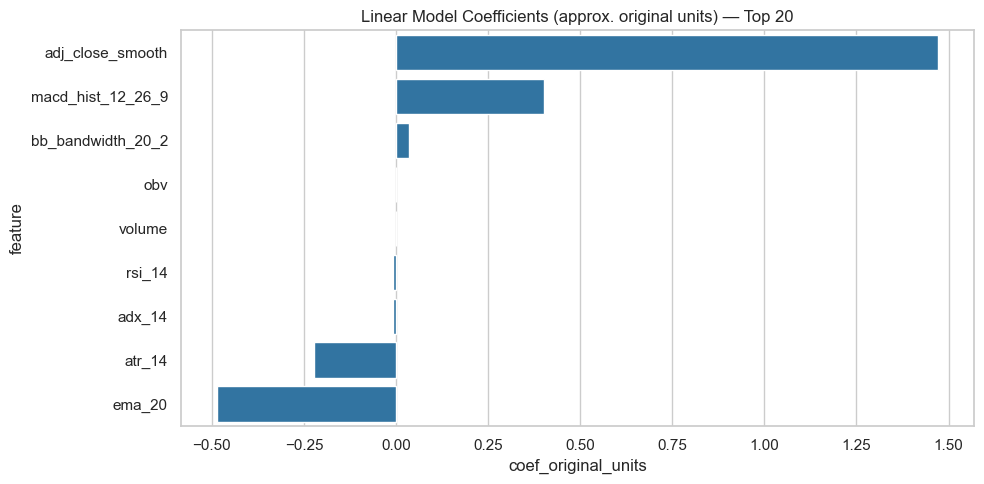

,feature,coef_scaled,coef_original_units
0,adj_close_smooth,1.471214e+00,1.471214e+00
1,macd_hist_12_26_9,4.012823e-01,4.012823e-01
2,bb_bandwidth_20_2,3.599231e-02,3.599231e-02
3,obv,5.910877e-11,5.910877e-11
4,volume,-4.103270e-09,-4.103270e-09
5,rsi_14,-9.434969e-03,-9.434969e-03
6,adx_14,-9.581351e-03,-9.581351e-03
7,atr_14,-2.215816e-01,-2.215816e-01
8,ema_20,-4.860486e-01,-4.860486e-01


In [110]:
# Coefficients (linear-family model)
scaler = None
linear_estimator = lin_model

coef_scaled = np.ravel(linear_estimator.coef_)

# If a scaler exists, convert coefficients back to original feature units
if scaler is not None and hasattr(scaler, "scale_"):
    coef_original_units = coef_scaled / scaler.scale_
else:
    coef_original_units = coef_scaled

coef_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "coef_scaled": coef_scaled,
            "coef_original_units": coef_original_units,
        }
    )
    .sort_values("coef_original_units", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df.head(20), x="coef_original_units", y="feature", color="#1f77b4")
plt.title("Linear Model Coefficients (approx. original units) — Top 20")
plt.tight_layout()
plt.show()

coef_df


## Model Justification

- Primary model is Linear Regression (assigned technique), giving a transparent baseline with interpretable coefficients.
- Ridge handles multicollinearity among trend-heavy features via L2 shrinkage.
- Huber regression is robust to outliers and can stabilize fit when price jumps create large residuals.
- Final recommendation should be based on the best test RMSE/MAE plus residual stability, not only training fit.